In [3]:
import numpy as np
import matplotlib.pyplot as plt
import scipy
from scipy.signal import find_peaks
from lib.readwav import *

In [5]:
#leggo il file note_musicali.csv creando un dizionario con chiave il nome della nota e valore della frequenza
note_musicali = {}
with open('note_musicali.csv', 'r') as f:
    for line in f:
        note, freq = line.strip().split(',')
        note_musicali[note] = float(freq)


#leggo il file delle fundamental frequencies
fundamental_frequencies = {}
data = np.loadtxt('fundamentals.csv')

# stampo la prima riga del file delle fundamental frequencies per verificare che sia stato letto correttamente
print(fundamental_frequencies)

{}


In [7]:
index = np.where(data <66)
print(index)

(array([ 36,  38, 140, 185, 205]),)


In [8]:
np.max(data)

np.float64(1563.3360474584158)

In [9]:
np.min(data)

np.float64(23.949108145191467)

In [11]:
# taglio il file note_musicali al massimo delle frequenze fondamentali e sotto al minimo delle frequenze fondamentali
note_musicali_cut = {k: v for k, v in note_musicali.items() if v < np.max(data) and v > np.min(data)}

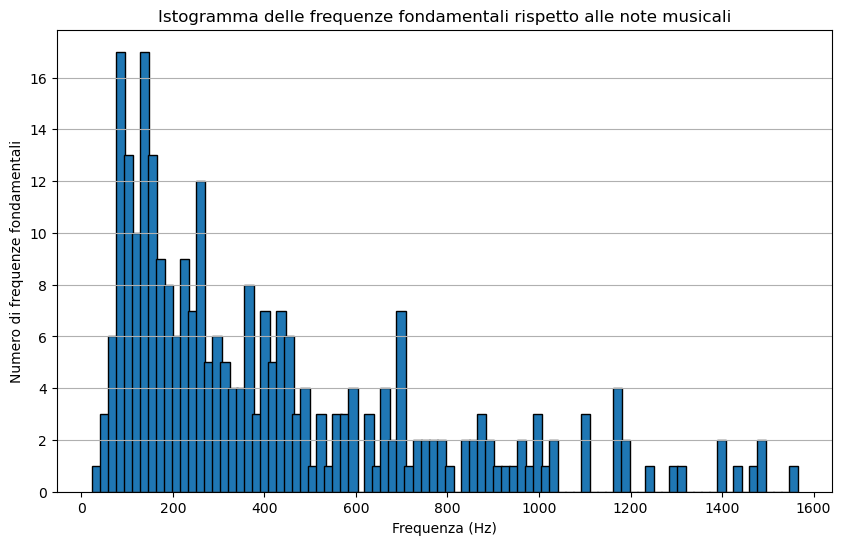

In [13]:
# guardo quante delle mie frequenze fondamentali sono presenti nel dizionario delle note musicali
#lo visualizzo con un istogramma
# i bin devono essere al centro delle frequenze delle note musicali ma larghi abbastanza da includere le frequenze fondamentali che sono vicine alle frequenze delle note musicali
# per ogni frequenza fondamentale, guardo se è presente nel dizionario delle note musicali
# se è presente, aggiungo 1 al bin corrispondente alla nota musicale

plt.figure(figsize=(10,6))
numero_bin = len(note_musicali)

larghezza_bin = 20 # Hz

plt.hist(data, bins=numero_bin, width=larghezza_bin, edgecolor='black')
plt.xlabel('Frequenza (Hz)')
plt.ylabel('Numero di frequenze fondamentali')
plt.title('Istogramma delle frequenze fondamentali rispetto alle note musicali')
# come tick metto il nome della nota musicale e la frequenza corrispondente
# e metto solo i tick dei bin che corrispondono alle frequenze delle note musicali


plt.grid(axis='y')
plt.show()